**1. SETUP & DATA LOADING**

1a) Importing Libraries:

In [ ]:
import pandas as pd #Data handeling: used for organizing data into tables (DataFrames)
import numpy as np # Math & Logic: Used for complex calculations and handeling arrays of number
import joblib # Saving/Loading: Used to export your tranied model (.pkl file) for your software app
import seaborn as sns #Charts(Advanced): Creates professional heatmaps and corelation charts
import matplotlib.pyplot as plt #Charts (Basic): Used to draw the actual line graphs and scatter plots
import shap #Explainable AI: The "Open the Black Box" too that shows what drives the price
import os # System Tools: Used to create folders and mange file paths on yoour google drive
import warnings # Clean Output: prevents messy (but harmless) warning messages from cluttering the code
import random #Optimixzation Tool: Used to randomly pick different combinations of model
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor #The ML Model: The high performance algorithm used to predict the electricty unit cost
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Accuracy Metrics: Used to cal the final scores
print("ALL LIBRARIES LOADED SUCCESSFULLY")

ALL LIBRARIES LOADED SUCCESSFULLY


1b) Mounting google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


1c)Load Data: reading Excel file and sorting by date

In [ ]:
file_path = "/content/drive/My Drive/Cost_prediction/energy_cost_physics_verified (1).xlsx"

df = pd.read_excel(file_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df['Date'].min().date(), "→", df['Date'].max().date())
print("Laod Demand range:", df['Load Demand\n(mWh)'].min(), "→", df['Load Demand\n(mWh)'].max())
print("Naphtha Price range:", df['Naphtha Price'].min(), "→", df['Naphtha Price'].max())
print("Coal Price range:", df['Coal Price\n(LKR)'].min(), "→", df['Coal Price\n(LKR)'].max())
print("FO Price range:", df['FO Price\n(LKR)'].min(), "→", df['FO Price\n(LKR)'].max())
print("Diesel Price range:", df['Diesel Price'].min(), "→", df['Diesel Price'].max())

df.head()

Shape: (2192, 21)
Date range: 2020-01-01 → 2025-12-31
Laod Demand range: 26799.18 → 47444.13
Naphtha Price range: 105.0 → 231.0
Coal Price range: 36.0 → 55.0
FO Price range: 130.0 → 270.0
Diesel Price range: 225.0 → 370.0


,Date,Major Hydro\n(GWh),Coal\n(GWh),Furnace Oil\n(GWh),Diesel\n(GWh),Naphtha\n(GWh),Wind CEB\n(GWh),Wind IPP\n(GWh),Solar Ground\n(GWh),Solar Rooftop\n(GWh),...,Total Gen\n(GWh),Unit Cost\n(LKR),Total Cost\n(LKR),FO Price\n(LKR),Coal Price\n(LKR),Naphtha Price,Diesel Price,Reservoir\n(GWh),Reservoir\n(%),Load Demand\n(mWh)
0,2020-01-01,25.717,5.221,0.0,0.0,0.0,0.792,0.672,0.600,1.067,...,39.653,9.869,364143.8,145.0,38.0,115.0,240.0,1108.717,87.42,36896.47
1,2020-01-02,25.493,4.399,0.0,0.0,0.0,0.779,0.651,0.581,0.987,...,38.715,9.921,345254.0,145.0,38.0,115.0,240.0,1108.002,87.37,34799.24
2,2020-01-03,25.494,4.694,0.0,0.0,0.0,0.795,0.673,0.573,0.949,...,38.974,9.890,355758.1,145.0,38.0,115.0,240.0,1107.275,87.31,35971.41
3,2020-01-04,25.454,5.200,0.0,0.0,0.0,0.777,0.679,0.602,1.153,...,39.432,9.922,328106.8,145.0,38.0,115.0,240.0,1106.323,87.23,33068.45
4,2020-01-05,25.480,5.169,0.0,0.0,0.0,0.758,0.692,0.605,1.183,...,39.432,10.186,314692.6,145.0,38.0,115.0,240.0,1106.463,87.24,30894.44


In [ ]:
print(df.columns.tolist())

['Date', 'Major Hydro\n(GWh)', 'Coal\n(GWh)', 'Furnace Oil\n(GWh)', 'Diesel\n(GWh)', 'Naphtha\n(GWh)', 'Wind CEB\n(GWh)', 'Wind IPP\n(GWh)', 'Solar Ground\n(GWh)', 'Solar Rooftop\n(GWh)', 'Mini Hydro\n(GWh)', 'Total Gen\n(GWh)', 'Unit Cost\n(LKR)', 'Total Cost\n(LKR)', 'FO Price\n(LKR)', 'Coal Price\n(LKR)', 'Naphtha Price', 'Diesel Price', 'Reservoir\n(GWh)', 'Reservoir\n(%)', 'Load Demand\n(mWh)']


**2. DATA PREPROCESSING**

2a) Renaming

In [ ]:
#CLEAN COLUMN NAMES
df.columns = [
    c.replace('\n', '_').replace(' ', '_')
     .replace('(', '').replace(')', '')
    for c in df.columns
]

In [ ]:
#RENAME COLUMNS
rename_map = {
    'Major_Hydro_GWh':      'major_hydro',
    'Coal_GWh':             'coal',
    'Furnace_Oil_GWh':      'furnace_oil',
    'Diesel_GWh':           'diesel',
    'Naphtha_GWh':          'naphtha',
    'Wind_CEB_GWh':         'wind_ceb',
    'Wind_IPP_GWh':         'wind_ipp',
    'Solar_Ground_GWh':     'solar_ground',
    'Solar_Rooftop_GWh':    'solar_rooftop',
    'Mini_Hydro_GWh':       'mini_hydro',
    'Total_Gen_GWh':        'total_gen',
    'Unit_Cost_LKR':        'unit_cost',
    'Total_Cost_LKR':       'total_cost',
    'FO_Price_LKR':         'fo_price',
    'Coal_Price_LKR':       'coal_price',
    'Naphtha_Price':        'naphtha_price',
    'Diesel_Price':         'diesel_price',
    'Reservoir_GWh':        'reservoir_gwh',
    'Reservoir_%':          'reservoir_pct',
    'Load_Demand_mWh':      'load_demand'
}
df = df.rename(columns=rename_map)

In [ ]:
print(df.columns.tolist())

['Date', 'major_hydro', 'coal', 'furnace_oil', 'diesel', 'naphtha', 'wind_ceb', 'wind_ipp', 'solar_ground', 'solar_rooftop', 'mini_hydro', 'total_gen', 'unit_cost', 'total_cost', 'fo_price', 'coal_price', 'naphtha_price', 'diesel_price', 'reservoir_gwh', 'reservoir_pct', 'load_demand']


2b)Data Cleaning

In [ ]:
#DATA QUALITY CHECK
print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("y range — unit_cost:",
      round(df['unit_cost'].min(), 2), "→",
      round(df['unit_cost'].max(), 2))


Missing values: 0
Duplicate rows: 0
y range — unit_cost: 8.0 → 38.2


2c)Normalization:Convert GWH -> MWH

In [ ]:
gwh_cols = [
    'major_hydro', 'coal', 'furnace_oil', 'diesel', 'naphtha',
    'wind_ceb', 'wind_ipp', 'solar_ground', 'solar_rooftop',
    'mini_hydro'
]

# Filter gwh_cols to only include columns that are actually present in df
existing_gwh_cols = [col for col in gwh_cols if col in df.columns]

if existing_gwh_cols:
    df[existing_gwh_cols] = df[existing_gwh_cols] * 1000
    print(f"Converted {existing_gwh_cols} from GWh to MWh.")
else:
    print("No relevant GWh columns found in DataFrame to convert at this stage.")

df.head(5)

Converted ['major_hydro', 'coal', 'furnace_oil', 'diesel', 'naphtha', 'wind_ceb', 'wind_ipp', 'solar_ground', 'solar_rooftop', 'mini_hydro'] from GWh to MWh.


,Date,major_hydro,coal,furnace_oil,diesel,naphtha,wind_ceb,wind_ipp,solar_ground,solar_rooftop,...,total_gen,unit_cost,total_cost,fo_price,coal_price,naphtha_price,diesel_price,reservoir_gwh,reservoir_pct,load_demand
0,2020-01-01,25717.0,5221.0,0.0,0.0,0.0,792.0,672.0,600.0,1067.0,...,39.653,9.869,364143.8,145.0,38.0,115.0,240.0,1108.717,87.42,36896.47
1,2020-01-02,25493.0,4399.0,0.0,0.0,0.0,779.0,651.0,581.0,987.0,...,38.715,9.921,345254.0,145.0,38.0,115.0,240.0,1108.002,87.37,34799.24
2,2020-01-03,25494.0,4694.0,0.0,0.0,0.0,795.0,673.0,573.0,949.0,...,38.974,9.890,355758.1,145.0,38.0,115.0,240.0,1107.275,87.31,35971.41
3,2020-01-04,25454.0,5200.0,0.0,0.0,0.0,777.0,679.0,602.0,1153.0,...,39.432,9.922,328106.8,145.0,38.0,115.0,240.0,1106.323,87.23,33068.45
4,2020-01-05,25480.0,5169.0,0.0,0.0,0.0,758.0,692.0,605.0,1183.0,...,39.432,10.186,314692.6,145.0,38.0,115.0,240.0,1106.463,87.24,30894.44


2d)Drop Leakage + Remove Redundant

In [ ]:
drop_leakage = ['total_cost', 'reservoir_gwh', 'total_gen']
df = df.drop(columns=[c for c in drop_leakage if c in df.columns])
#loop through potential leakage cols and drop them only if they exist in the

**3. FEATURE ENGINEERING**

3a)Aggregation: Combing related sources

In [ ]:
df['solar'] = df['solar_ground']  + df['solar_rooftop']
df['total_thermal'] = df['furnace_oil']   + df['diesel'] + df['naphtha']
df['wind'] = df['wind_ceb'] + df['wind_ipp']

3b)Temporal Features:

In [ ]:
#CYCLICAL MONTH ENCODING
month = df['Date'].dt.month
df['month_sin'] = np.sin(2 * np.pi * month / 12)
df['month_cos'] = np.cos(2 * np.pi * month / 12)
#sin & cos convert month into a circular position, so the model understands that time repeats (Dec->Jan)

3c) Ratio Features

In [ ]:
df['thermal_ratio_ld'] = df['total_thermal'] / df['load_demand']
df['hydro_ratio_ld']   = df['major_hydro']   / df['load_demand']
df['coal_ratio_ld']    = df['coal']          / df['load_demand']

3c)Interaction Features:

In [ ]:
df['thermal_x_fo']      = df['total_thermal'] * df['fo_price']
df['thermal_x_diesel']  = df['total_thermal'] * df['diesel_price']
df['thermal_x_naphtha'] = df['total_thermal'] * df['naphtha_price']
df['coal_x_coalprice']  = df['coal']          * df['coal_price']

In [ ]:
print("Shape:", df.shape)

Shape: (2192, 30)


**4. EXPLORATORY DATA ANALYSIS (EDA)**

4a)Correlation Analysis-analysis of all the fetaures.

In [ ]:

print("\n--- CORRELATION MATRIX ---")


# Keep only numeric columns and drop rows with NaNs (for clean math)
num_df = df.dropna().select_dtypes(include=[np.number])


# Make sure target exists
if 'unit_cost' not in num_df.columns:
    raise KeyError("Column 'unit_cost' not found. Check your rename_map and column names.")


# Full correlation matrix
corr_matrix = num_df.corr()#computes Pearson corelation between every pair of numeric columns


# Correlation of each feature with target
corr_with_target = corr_matrix['unit_cost'].sort_values(ascending=False)
print("\nCorrelation with unit_cost (top 20):")
print(corr_with_target.head(20))
print("\nCorrelation with unit_cost (bottom 20):")
print(corr_with_target.tail(20))


--- CORRELATION MATRIX ---

Correlation with unit_cost (top 20):
unit_cost            1.000000
coal_x_coalprice     0.802350
thermal_x_fo         0.800110
thermal_x_diesel     0.795117
thermal_x_naphtha    0.788436
thermal_ratio_ld     0.743363
total_thermal        0.740898
furnace_oil          0.679244
coal                 0.679153
naphtha_price        0.663217
naphtha              0.638729
coal_ratio_ld        0.607228
diesel_price         0.588958
coal_price           0.577968
fo_price             0.557549
load_demand          0.476651
diesel               0.466762
solar                0.397271
solar_rooftop        0.384537
month_sin            0.117762
Name: unit_cost, dtype: float64

Correlation with unit_cost (bottom 20):
naphtha_price     0.663217
naphtha           0.638729
coal_ratio_ld     0.607228
diesel_price      0.588958
coal_price        0.577968
fo_price          0.557549
load_demand       0.476651
diesel            0.466762
solar             0.397271
solar_rooftop     

In [ ]:
#DROP REDUNDANT, WEAK COLUMNS
drop_features = [
    # Sub-columns already aggregated
    'wind_ceb', 'wind', 'wind_ipp',
    'solar_ground', 'solar_rooftop',
    'furnace_oil', 'diesel', 'naphtha',
    'mini_hydro', 'total_thermal',
    'load_demand',

    # Weak / risky
    'reservoir_pct',
    'coal',
    'solar',
    'month_sin', 'month_cos',

]

df = df.drop(columns=[c for c in drop_features if c in df.columns], errors='ignore')
print(f"DROPPED {len([c for c in drop_features if c in df.columns])} columns")
print(f"FINAL SHAPE: {df.shape}")
print("KEPT FEATURES:", [c for c in df.columns if c not in ['Date', 'unit_cost']])


DROPPED 0 columns
FINAL SHAPE: (2192, 14)
KEPT FEATURES: ['major_hydro', 'fo_price', 'coal_price', 'naphtha_price', 'diesel_price', 'thermal_ratio_ld', 'hydro_ratio_ld', 'coal_ratio_ld', 'thermal_x_fo', 'thermal_x_diesel', 'thermal_x_naphtha', 'coal_x_coalprice']


4b)CHART 1: Statistical Distribution-Histogram showing the spead of the Unit Cost

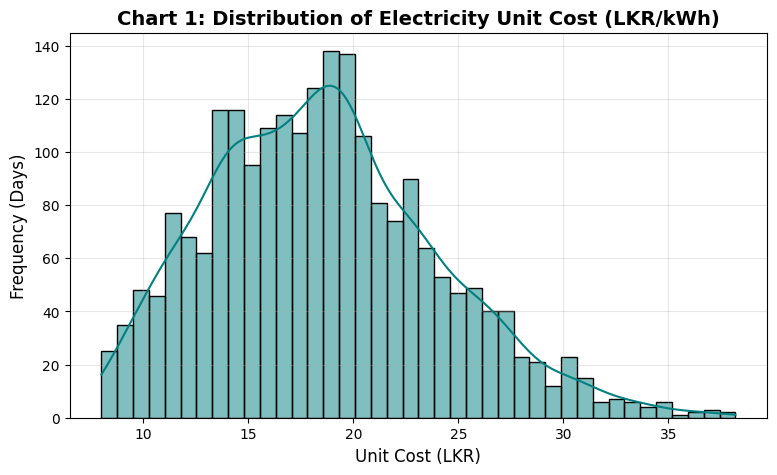

In [ ]:
plt.figure(figsize=(9, 5)) # create a new plot area
sns.histplot(df['unit_cost'], bins=40, kde=True, color='teal')
plt.title("Chart 1: Distribution of Electricity Unit Cost (LKR/kWh)", fontsize=14, fontweight='bold')
plt.xlabel("Unit Cost (LKR)", fontsize=12)
plt.ylabel("Frequency (Days)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

##The uni cost is mostly packed between 12-25 LKR, with a peak around 18-20 LKR,
# inicating typical daily values. the distribution is right skewed,
#meaning most days have moderate costs but there are occasional higher-csot spikes above 30 LKR.


4c)CHART 2: Correlation Analysis- Final Correlation Matrix & Heatmap after dropping features


--- Final Features Correlated with Unit Cost (Linear) ---
unit_cost            1.0000
coal_x_coalprice     0.8024
thermal_x_fo         0.8001
thermal_x_diesel     0.7951
thermal_x_naphtha    0.7884
thermal_ratio_ld     0.7434
naphtha_price        0.6632
coal_ratio_ld        0.6072
diesel_price         0.5890
coal_price           0.5780
fo_price             0.5575
major_hydro         -0.7153
hydro_ratio_ld      -0.7522


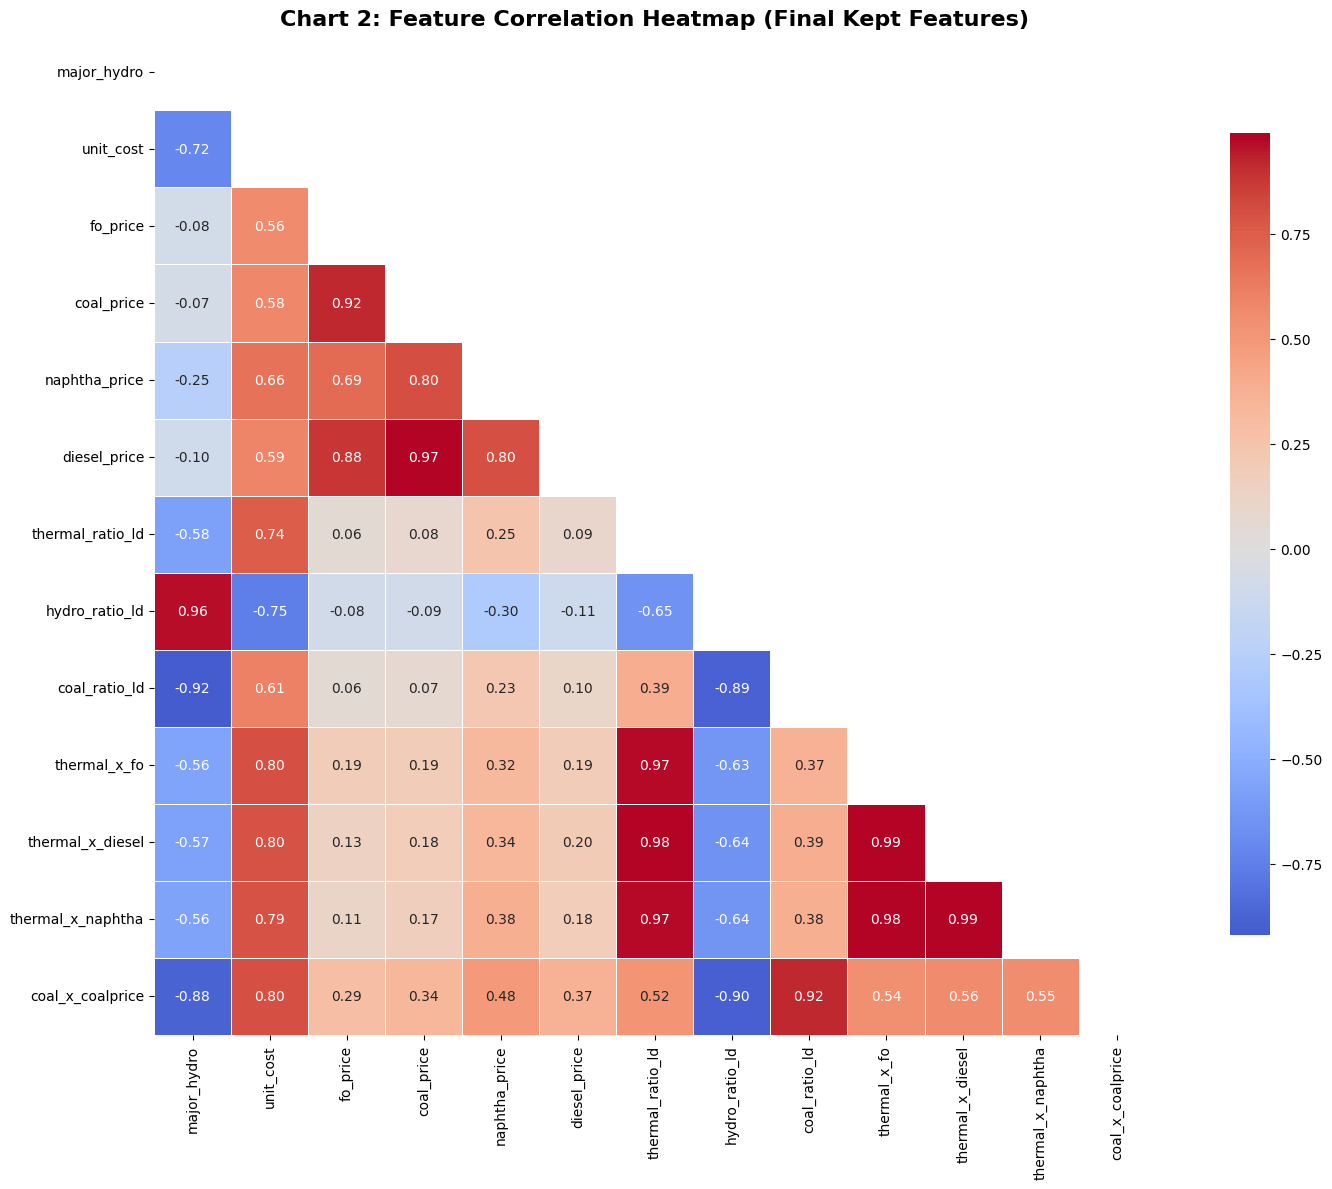

In [ ]:
# Select only numeric columns (this prevents errors from the 'Date' column)
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Print the exact numbers to the console
print("\n--- Final Features Correlated with Unit Cost (Linear) ---")
corr_with_target = corr_matrix['unit_cost'].sort_values(ascending=False)
print(corr_with_target.round(4).to_string())

# Draw the Heatmap
plt.figure(figsize=(16, 12))

#create a 'mask' to hide the upper triangle of the heatmap.
# This stops duplicate information from showing up and makes the chart look highly professional.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Chart 2: Feature Correlation Heatmap (Final Kept Features)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
#The heatmap helped remove 11 highly correlated variables,
#leaving 19 independent predictors, improving model accuracy and confirming realistic relationships
#like reservoir levels matching hydro power generation.
#

4e)CHART 3: Linearity Check-Scatter Plots for Top 4 Drivers

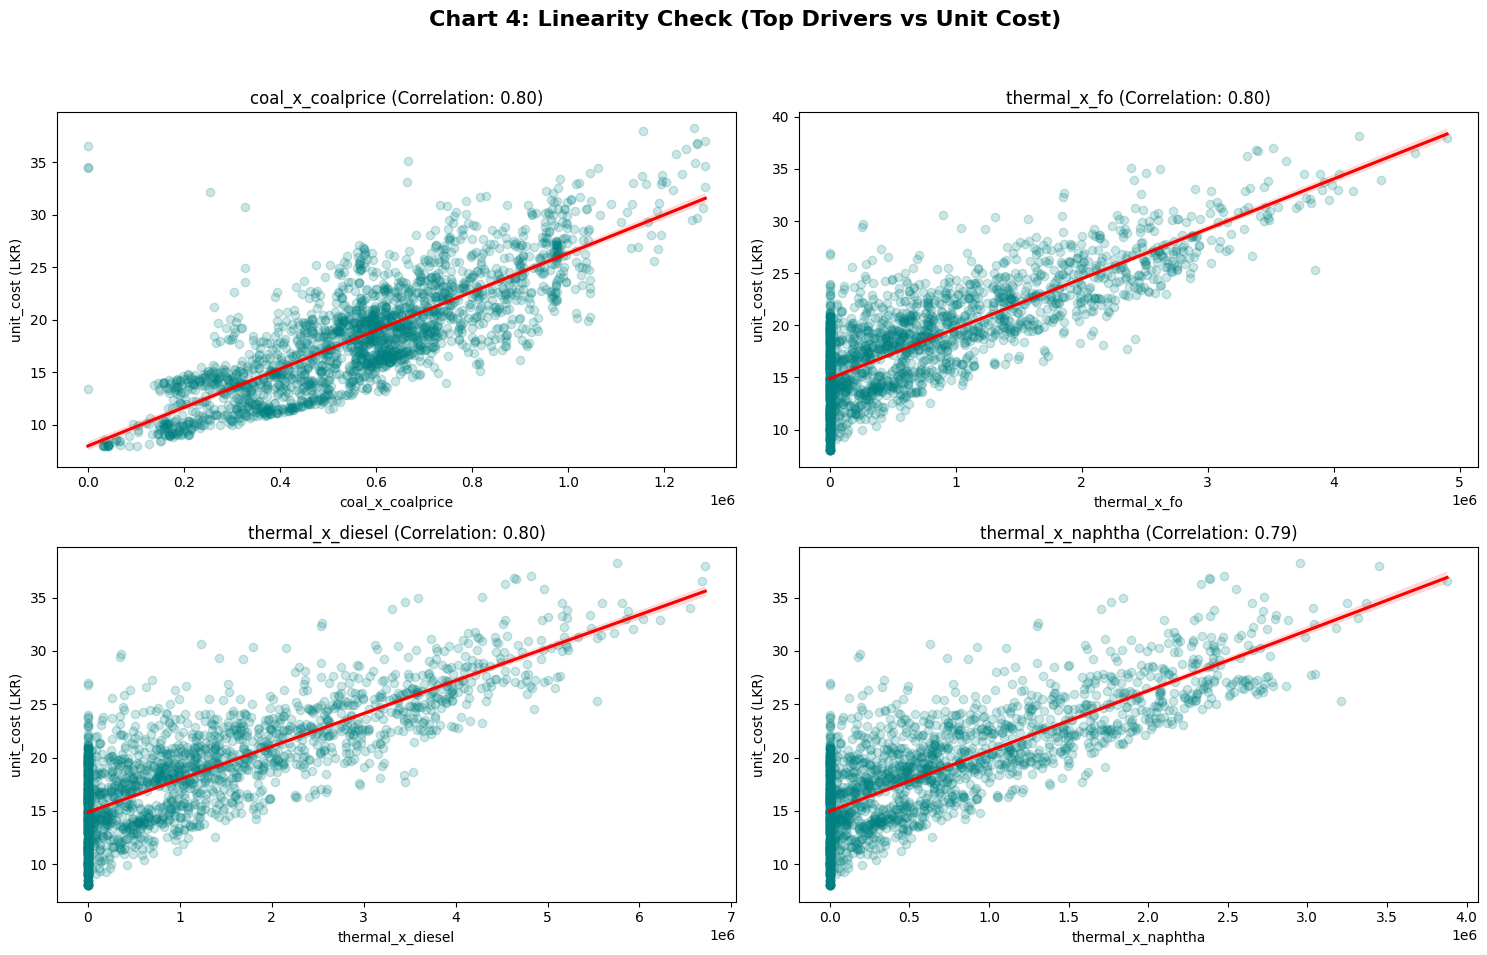

In [ ]:
# 📊 CHART 4: Scatter Plots for Top 4 Drivers
# We pick the top 4 based on the correlation math we just did
top_4_features = corr_with_target.drop('unit_cost').abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Chart 4: Linearity Check (Top Drivers vs Unit Cost)', fontsize=16, fontweight='bold')

for i, feat in enumerate(top_4_features):
    ax = axes[i//2, i%2]
    sns.regplot(data=df, x=feat, y='unit_cost', ax=ax,
                scatter_kws={'alpha':0.2, 'color':'teal'},
                line_kws={'color':'red'})

    r_val = corr_with_target[feat]
    ax.set_title(f"{feat} (Correlation: {r_val:.2f})", fontsize=12)
    ax.set_xlabel(feat)
    ax.set_ylabel("unit_cost (LKR)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
#The graph shows strong positive relationships between key fuel factors and electricity unit cost,
#where higher fuel use and prices increase costs (~0.79–0.80 correlation).
#XGBoost was chosen for its ability to handle non-linearity, feature interactions,
#and correlated data, giving accurate predictions.

**5. DEFINE FEATURES AND TARGETS**

In [ ]:
drop_from_X = ['Date', 'unit_cost']
features = [c for c in df.columns if c not in drop_from_X]

X = df[features]
y = df['unit_cost']

print(f"\n Features defined: {len(features)} total")
print("Features going into model:")
for f in features:
    print(f"  - {f}")
print(f"\nTarget: unit_cost (LKR/kWh)")

#Fuel prices are kept with their interaction features
#because XGBoost splits one feature at a time,
#so the raw price helps distinguish whether a low interaction value
#comes from low fuel price or low generation.



 Features defined: 12 total
Features going into model:
  - major_hydro
  - fo_price
  - coal_price
  - naphtha_price
  - diesel_price
  - thermal_ratio_ld
  - hydro_ratio_ld
  - coal_ratio_ld
  - thermal_x_fo
  - thermal_x_diesel
  - thermal_x_naphtha
  - coal_x_coalprice

Target: unit_cost (LKR/kWh)


**6. TRAIN/TEST SPLIT (2020-2024 ->2025)**

Data Splitting: Traning vs Holdout SET (2025)

In [ ]:
TEST_MONTHS = 12 #Define the size of the 'final-traning'. (1 year)
split_date = df['Date'].max() - pd.DateOffset(months=TEST_MONTHS)#find last date substarct 12 find our test  data
#this variable holds the sepcifc calaneder date

train_mask = df['Date'] <= split_date #true for anydate on or before our split_date(past)
test_mask  = df['Date'] > split_date # true for any date after split_date (future)

X_train = X[train_mask] #X_train uses train_mask to take all input columns orm 2020 to 2024
X_test  = X[test_mask] #'X_test' uses 'test_mask' to take all input columns from 2025.
y_train = y[train_mask] #'y_train' gets the actual prices the model will learn from.
y_test  = y[test_mask] # 'y_test' gets the actual prices we will use to check if the model is right.

print(f"\n✅ Train: {X_train.shape} → {df['Date'][train_mask].min().date()} to {df['Date'][train_mask].max().date()}")
print(f"✅ Test:  {X_test.shape} → {df['Date'][test_mask].min().date()} to {df['Date'][test_mask].max().date()}")


✅ Train: (1827, 12) → 2020-01-01 to 2024-12-31
✅ Test:  (365, 12) → 2025-01-01 to 2025-12-31


**7. HYPERPARAMETER TUNING+WALK-FORWARD VALIDATION**

7a)Validation Setup

In [ ]:
# Define rolling window CV
# Step 1 — Define your exact rolling window folds
walk_folds = [
    # ('Name', 'Train Start', 'Train End', 'Test Start', 'Test End')

    # Fold 1: Train 2020 to 2022 -> Test early 2023
    ('Early 2023', '2020-01-01', '2022-12-31', '2023-01-01', '2023-06-30'),#learn 1st 3 years and predict 6 months

    # Fold 2: Train 2020 to mid-2023 -> Test late 2023
    ('Late 2023',  '2020-01-01', '2023-06-30', '2023-07-01', '2023-12-31'), #"Walk Forward" by adding 6 months of new data to the training.

    # Fold 3: Train 2020 to 2023 -> Test early 2024
    ('Early 2024', '2020-01-01', '2023-12-31', '2024-01-01', '2024-06-30'),#smart knows end of 2003, challenge predict cost for 2024

    # Fold 4: Train 2020 to mid-2024 -> Test late 2024
    ('Late 2024',  '2020-01-01', '2024-06-30', '2024-07-01', '2024-12-31'),#preict final 2024 months

]
print(f"✅ Defined {len(walk_folds)} Validation Folds (6-month windows)")


✅ Defined 4 Validation Folds (6-month windows)


Why this structure?
An expanding window is used so the training set grows over time, mimicking real-world use with more historical data each month. The 6-month splits align with Sri Lanka’s monsoon cycles, ensuring the model is tested on both hydro-heavy and thermal-heavy periods.

7b)Hyperparameter Optimization: Random Search Setup

In [ ]:
# Step 2 — Parameter grid
param_dist = {
    # How many "Trees" the model builds. More trees = more complexity.
    'n_estimators':     [800, 1000, 1500],
    # The "Step Size" for learning. Smaller means more careful learning.
    'learning_rate':    [0.03, 0.05, 0.08],
    # How deep each tree can grow. Level 3 or 4 prevents the model from "memorizing" noise.
    'max_depth':        [3, 4],
    # What % of data the model looks at for each tree (to prevent bias).
    'subsample':        [0.8, 0.85, 0.9],
    # What % of columns the model looks at for each tree.
    'colsample_bytree': [0.7, 0.8],
    # Minimum data points needed in a leaf. Higher values prevent overfitting.
    'min_child_weight': [3, 5, 7],
    # A "penalty" for making complex moves (Regularization)
    'gamma':            [0.1, 0.3, 0.5],
    # L1 and L2 Regularization: These keep the "weights" of the features small.
    'reg_alpha':        [0.5, 1.0, 2.0],
    'reg_lambda':       [1.0, 2.0, 5.0]
}

# Step 3 — Manual random search over walk-forward folds
random.seed(42) # randome choice is same everytime

# Sample 40 random parameter combinations
param_keys   = list(param_dist.keys()) # Extract just the names of the settings (n_estimators, max_depth, etc.) into a list.
param_combos = [] # Create an empty list to store our 40 combinations
# Loop 40 times to create 40 unique sets of settings.
for _ in range(40):
    # For every key, pick one random choice from the lists we defined above.
    combo = {k: random.choice(param_dist[k]) for k in param_keys}
    # Add this specific combination to our master list.
    param_combos.append(combo)

print(f"✅ Generated {len(param_combos)} parameter combinations for testing")

✅ Generated 40 parameter combinations for testing


7c)Model Tuning: Evalluating Parameters across All Folds

In [ ]:
# Step 4 — Evaluate each combo across all 4 folds
print("Searching best parameters using Walk-Forward CV...")
print(f"Testing {len(param_combos)} combinations × {len(walk_folds)} folds\n")

# Initialize variables to keep track of the "High Score" (R²) and the settings that achieved it.
# 'i' is the counter (0 to 39), 'params' is the current dictionary of settings.
best_avg_r2 = -999 # start low so real score will be able to beat it
best_params = None
results     = [] #store scores of teh parameter


# The Outer Loop: Iterate through each of the 40 random parameter combinations.
for i, params in enumerate(param_combos):
    fold_r2s = [] # Reset the score list for this specific combination.


  # The Inner Loop: Test the CURRENT 'params' on each of our 4 'Walk-Folds'.
    for name, tr_start, tr_end, te_start, te_end in walk_folds:

        # Create masks to pick the training and testing rows based on the fold's dates.
        train_mask = (df['Date'] >= tr_start) & (df['Date'] <= tr_end)
        test_mask  = (df['Date'] >= te_start) & (df['Date'] <= te_end)

        # Slice the data into Training and Testing sets for this specific fold.
        X_tr = X[train_mask]
        y_tr = y[train_mask]
        X_te = X[test_mask]
        y_te = y[test_mask]

        # Initialize the XGBoost model using the current candidate 'params'.
        model = XGBRegressor(random_state=42, n_jobs=-1, **params)
        model.fit(X_tr, y_tr)
        r2 = r2_score(y_te, model.predict(X_te))
        fold_r2s.append(r2)

    # After testing on all 4 folds, calculate the AVERAGE R² for this parameter set.
    avg_r2 = np.mean(fold_r2s)
    results.append((avg_r2, params))
    # "The Leaderboard Logic": If this average is better than our previous best, update the parameters.
    if avg_r2 > best_avg_r2:
        best_avg_r2 = avg_r2
        best_params = params

    #Every 10 combinations, print the current high score.
    if (i + 1) % 10 == 0:
        print(f"  Combo {i+1}/40 done — best so far: {round(best_avg_r2, 4)}")

print(f"\nBest Walk-Forward CV R²: {round(best_avg_r2, 4)}")
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\n✅ BEST CV R²: {round(best_avg_r2, 4)}")
print("Optimized Parameters:", best_params)

Searching best parameters using Walk-Forward CV...
Testing 40 combinations × 4 folds

  Combo 10/40 done — best so far: 0.8227
  Combo 20/40 done — best so far: 0.8227
  Combo 30/40 done — best so far: 0.8227
  Combo 40/40 done — best so far: 0.8227

Best Walk-Forward CV R²: 0.8227
Best parameters:
  n_estimators: 1500
  learning_rate: 0.03
  max_depth: 3
  subsample: 0.9
  colsample_bytree: 0.8
  min_child_weight: 3
  gamma: 0.1
  reg_alpha: 0.5
  reg_lambda: 5.0

✅ BEST CV R²: 0.8227
Optimized Parameters: {'n_estimators': 1500, 'learning_rate': 0.03, 'max_depth': 3, 'subsample': 0.9, 'colsample_bytree': 0.8, 'min_child_weight': 3, 'gamma': 0.1, 'reg_alpha': 0.5, 'reg_lambda': 5.0}


7d)Validation performence: Fold by fold audit

In [ ]:
print("\n" + "="*60)
print("INDIVIDUAL FOLD RESULTS WITH BEST PARAMETERS")
print("="*60)

# Create a list to store the R² scores of our final "Best" model across all folds.
best_fold_r2s = []
# Loop through our 4 predefined time-folds (Early 2023, Late 2023, etc.).
for name, tr_start, tr_end, te_start, te_end in walk_folds:
  # Create filters (masks) to pick rows based on the current fold's dates.
    train_mask = (df['Date'] >= tr_start) & (df['Date'] <= tr_end)
    test_mask  = (df['Date'] >= te_start) & (df['Date'] <= te_end)

    # Slice the data into training (history) and testing (future) variables.
    X_tr = X[train_mask]; y_tr = y[train_mask]
    X_tr = X[train_mask]; y_tr = y[train_mask]
    X_te = X[test_mask];  y_te = y[test_mask]

    # Initialize the model using the WINNING parameters we found in the search.
    # We use 'random_state=42' to keep results consistent and 'n_jobs=-1'
    fold_model = XGBRegressor(random_state=42, n_jobs=-1, **best_params)

    fold_model.fit(X_tr, y_tr)

    # Make predictions for the 6-month test window.
    y_fold_pred = fold_model.predict(X_te)

    fold_r2   = r2_score(y_te, y_fold_pred)
    fold_mae  = mean_absolute_error(y_te, y_fold_pred)
    fold_rmse = mean_squared_error(y_te, y_fold_pred) ** 0.5
    best_fold_r2s.append(fold_r2)

    print(f"\n  {name}")
    print(f"  Train Window: {df['Date'][train_mask].min().date()} to {df['Date'][train_mask].max().date()} ({len(X_tr)} days)")
    print(f"  Test Window : {df['Date'][test_mask].min().date()} to {df['Date'][test_mask].max().date()} ({len(X_te)} days)")
    print(f"  R²  : {fold_r2:.4f}")
    print(f"  MAE : {fold_mae:.4f} LKR/kWh")
    print(f"  RMSE: {fold_rmse:.4f} LKR/kWh")

print("\n" + "="*60)
print(f"  Average R² : {np.mean(best_fold_r2s):.4f}")
# The Standard Deviation (Std) shows if the model is "stable".
# A low Std means the model performs similarly in all seasons.
print(f"  Std R²     : {np.std(best_fold_r2s):.4f}")



INDIVIDUAL FOLD RESULTS WITH BEST PARAMETERS

  Early 2023
  Train Window: 2020-01-01 to 2022-12-31 (1096 days)
  Test Window : 2023-01-01 to 2023-06-30 (181 days)
  R²  : 0.9654
  MAE : 0.8845 LKR/kWh
  RMSE: 1.0751 LKR/kWh

  Late 2023
  Train Window: 2020-01-01 to 2023-06-30 (1277 days)
  Test Window : 2023-07-01 to 2023-12-31 (184 days)
  R²  : 0.7607
  MAE : 1.0294 LKR/kWh
  RMSE: 1.5965 LKR/kWh

  Early 2024
  Train Window: 2020-01-01 to 2023-12-31 (1461 days)
  Test Window : 2024-01-01 to 2024-06-30 (182 days)
  R²  : 0.6968
  MAE : 1.6859 LKR/kWh
  RMSE: 2.3232 LKR/kWh

  Late 2024
  Train Window: 2020-01-01 to 2024-06-30 (1643 days)
  Test Window : 2024-07-01 to 2024-12-31 (184 days)
  R²  : 0.8680
  MAE : 1.0130 LKR/kWh
  RMSE: 1.2590 LKR/kWh

  Average R² : 0.8227
  Std R²     : 0.1026


12 vs 6
The 12-month holdout is used as a “final test” to ensure the model works across all seasons (monsoons and dry periods), proving year-round reliability. The 6-month windows are used earlier for tuning, allowing faster, repeated testing to refine the model’s performance.

**8. FINAL MASTER MODEL & UNSEEN HOLDOUT EVALUATION (2025)**

In [ ]:
print("\n" + "="*60)
print("🏆 FINAL MASTER MODEL: EVALUATING ON UNSEEN 2025 DATA")
print("="*60)

# Step 1: Train the master model on ALL training data (2020 - 2024)
# We use the winning 'best_params' from the Walk-Forward CV
final_model = XGBRegressor(random_state=42, n_jobs=-1, **best_params)
final_model.fit(X_train, y_train)

# Step 2: Make predictions on the locked 2025 Holdout Set
y_pred_2025 = final_model.predict(X_test)

# Step 3: Calculate Final Board Exam Scores
final_r2   = r2_score(y_test, y_pred_2025)
final_mae  = mean_absolute_error(y_test, y_pred_2025)
final_rmse = mean_squared_error(y_test, y_pred_2025) ** 0.5

print(f"✅ Final Holdout R²   : {final_r2:.4f}")
print(f"✅ Final Holdout MAE  : {final_mae:.4f} LKR/kWh")
print(f"✅ Final Holdout RMSE : {final_rmse:.4f} LKR/kWh")


🏆 FINAL MASTER MODEL: EVALUATING ON UNSEEN 2025 DATA
✅ Final Holdout R²   : 0.8995
✅ Final Holdout MAE  : 0.7698 LKR/kWh
✅ Final Holdout RMSE : 1.2564 LKR/kWh


**9. VISUALIZATION**

9a) CHART 5: (Training vs Unseen Data)

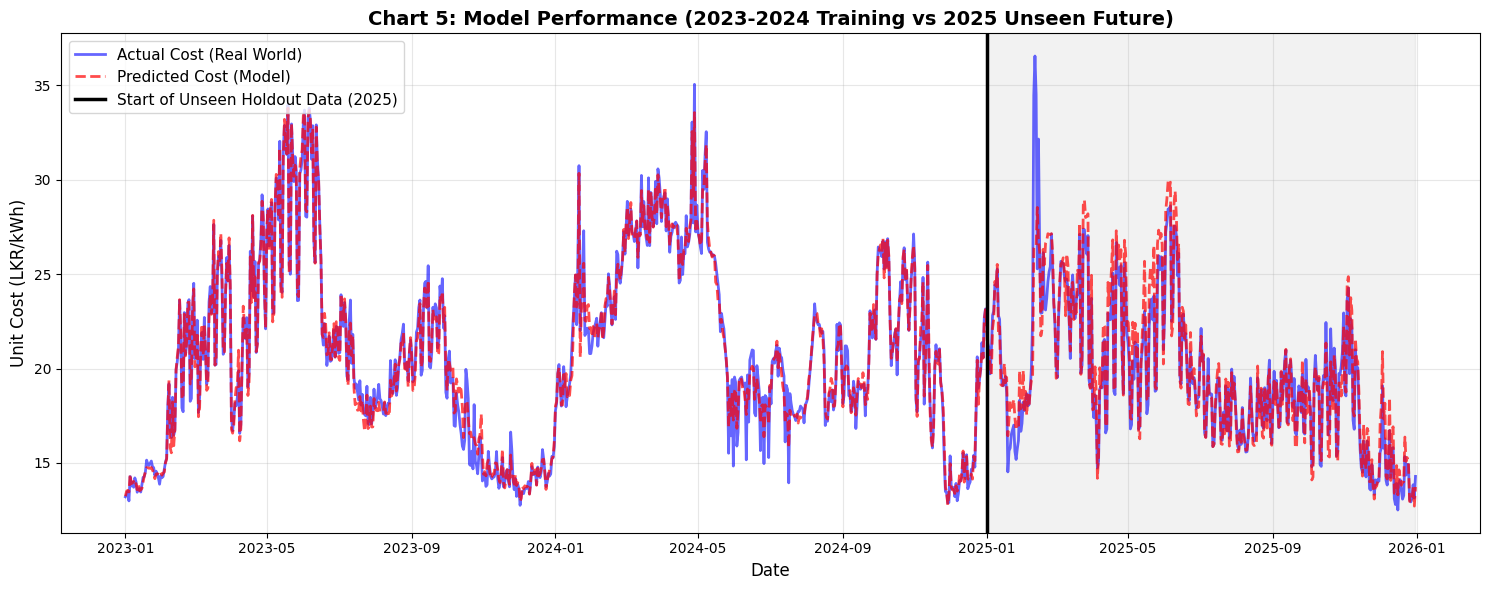

In [ ]:
# We use 'final_model' (trained only up to 2024) to see what it thinks
# about the past AND the future 2025 data it has never seen before.
y_pred_all = final_model.predict(X)

plt.figure(figsize=(15, 6))

# We filter the plot to start from 2023 so it's easy to read the recent crises
plot_mask = df['Date'] >= '2023-01-01'

plt.plot(df['Date'][plot_mask], y[plot_mask], label='Actual Cost (Real World)', color='blue', alpha=0.6, linewidth=2)
plt.plot(df['Date'][plot_mask], y_pred_all[plot_mask], label='Predicted Cost (Model)', color='red', alpha=0.7, linewidth=2, linestyle='--')

# Draw the "Deployment" Cutoff Line for 2025
unseen_start_date = pd.to_datetime('2025-01-01')
plt.axvline(unseen_start_date, color='black', linestyle='-', linewidth=2.5, label='Start of Unseen Holdout Data (2025)')

# Add a background shade to highlight the unseen future
plt.axvspan(unseen_start_date, df['Date'].max(), color='grey', alpha=0.1)

plt.title("Chart 5: Model Performance (2023-2024 Training vs 2025 Unseen Future)", fontsize=14, fontweight='bold')
plt.ylabel("Unit Cost (LKR/kWh)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**10 FEATURE IMPORTANCE (SHAP ANALYSIS ON 2025 HOLDOUT)**

10a) Graph of SHAP (2025 Holdout)


🧠 CALCULATING SHAP FEATURE IMPORTANCE


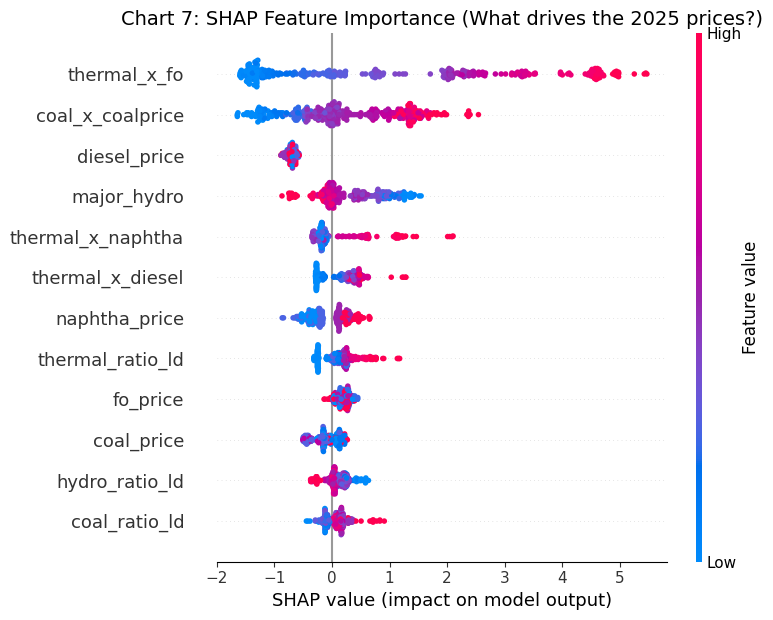

In [ ]:
print("\n" + "="*60)
print("🧠 CALCULATING SHAP FEATURE IMPORTANCE")
print("="*60)

# 1. Create the SHAP Explainer using your Final Master Model
explainer = shap.TreeExplainer(final_model)

# 2. Calculate SHAP values specifically on the unseen 2025 test data
shap_values = explainer.shap_values(X_test)

# 3. 📊 CHART 7: SHAP Summary Plot (The most powerful chart for the panel)
plt.figure(figsize=(10, 6))
plt.title("Chart 7: SHAP Feature Importance (What drives the 2025 prices?)", fontsize=14)
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

This SHAP plot shows which features most influence electricity unit cost and how they impact predictions. The top drivers such as thermal × FO, coal × coal price, and other thermal fuel interactions have the strongest effect, with higher values pushing costs up on the right side. Each point represents a data instance, colored by feature value where red means high and blue means low, showing how changes in fuel usage and prices affect the model output. SHAP was used because it provides clear, interpretable insights into feature importance and explains how each variable contributes to predictions, making the model more transparent.

10b) Global feature importance: macroeconomic impact analysis

In [ ]:
print("\n" + "="*60)
print("🌍 GLOBAL SHAP: WHICH FEATURES INCREASE OR DECREASE COST (ALL YEARS)?")
print("="*60)

# 1. Calculate SHAP values on the ENTIRE dataset (X) instead of just X_test
# This finds the contribution of every feature for every single day from 2020-2025.
shap_values_global = explainer.shap_values(X)

#store human fidings
directional_impacts_global = []

# Loop through every feature in the FULL dataset (X)
for i, col in enumerate(X.columns):
  # Get the raw physical values for this feature (e.g., actual oil prices).
    feature_vals = X[col].values

    # SHAP output format can vary; this ensures we are grabbing the correct
    # array of importance values for the current feature.
    if isinstance(shap_values_global, list):
        shap_vals = shap_values_global[0][:, i]
    else:
        shap_vals = shap_values_global[:, i]

    # Find days where this feature's value was ABOVE AVERAGE
    mean_val = np.mean(feature_vals)
    high_mask = feature_vals > mean_val

   # Calculate the average Rupee (LKR) impact on the price for those "High" days.
    if np.sum(high_mask) > 0:
        impact_when_high = np.mean(shap_vals[high_mask])
    else:
        impact_when_high = 0

    # Calculate overall importance just so we can sort the table
    mean_abs_impact = np.mean(np.abs(shap_vals))

    # Determine the human-readable direction
    if impact_when_high > 0.1:
        effect = "INCREASES Cost"
    elif impact_when_high < -0.1:
        effect = "DECREASES Cost"
    else:
        effect = "Neutral / Mixed"


    directional_impacts_global.append({
        'Feature': col,
        'Overall_Importance': mean_abs_impact,
        'Impact_When_HIGH_(LKR)': impact_when_high,
        'Behavior': effect
    })

# Convert to DataFrame, sort by importance, and format it
direction_global_df = pd.DataFrame(directional_impacts_global)
direction_global_df = direction_global_df.sort_values('Overall_Importance', ascending=False)
direction_global_df['Impact_When_HIGH_(LKR)'] = direction_global_df['Impact_When_HIGH_(LKR)'].round(4)
direction_global_df = direction_global_df.drop(columns=['Overall_Importance'])

print(direction_global_df.to_string(index=False))


🌍 GLOBAL SHAP: WHICH FEATURES INCREASE OR DECREASE COST (ALL YEARS)?
          Feature  Impact_When_HIGH_(LKR)       Behavior
     thermal_x_fo                  2.4880 INCREASES Cost
 coal_x_coalprice                  1.1310 INCREASES Cost
     diesel_price                  0.4058 INCREASES Cost
         fo_price                  0.7076 INCREASES Cost
       coal_price                  0.4604 INCREASES Cost
      major_hydro                 -0.4132 DECREASES Cost
    naphtha_price                  0.1873 INCREASES Cost
 thermal_x_diesel                  0.3909 INCREASES Cost
thermal_x_naphtha                  0.1898 INCREASES Cost
 thermal_ratio_ld                  0.2842 INCREASES Cost
    coal_ratio_ld                  0.2084 INCREASES Cost
   hydro_ratio_ld                 -0.1121 DECREASES Cost


**11.PRODUCTION DEPLYMENT **

In [ ]:
# Define your specific path
save_path = '/content/drive/My Drive/Cost_prediction/'

# Create the folder if it doesn't exist yet
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f"Created new folder: {save_path}")
print("\n" + "="*60)
print("🚀 TRAINING FINAL PRODUCTION MODEL ON ALL DATA (2020-2025)")
print("="*60)

# 1. Initialize the model with the BEST parameters found during CV
# We use the winning 'best_params' from the Walk-Forward script
production_model = XGBRegressor(random_state=42, n_jobs=-1, **best_params)

# 2. Train on the ENTIRE dataset (X and y)
# No more splits—this is the model's "Full Education"
production_model.fit(X, y)

# 3. Save the files directly to your Google Drive folder
# Correction for Production Section
model_filename = os.path.join(save_path, 'energy_cost_model_final.pkl')
features_filename = os.path.join(save_path, 'features_list.pkl')

# Use production_model here!
joblib.dump(production_model, model_filename)
joblib.dump(features, features_filename)

print("\n✅ SUCCESS: Final Production Model & Feature Map have been exported!")
print(f"📍 Location: {save_path}")
print(f"📦 Files: energy_cost_model_final.pkl, features_list.pkl")

# ==============================================================================
# 15. QUICK SMOKE TEST (Verification)
# ==============================================================================
# Let's see what the model thinks the price is for the very last day of your data
last_day_pred = production_model.predict(X.tail(1))
actual_last_day = y.iloc[-1]

print(f"\n--- Production Model Verification ---")
print(f"Last Day in Data: {df['Date'].max().date()}")
print(f"Actual Unit Cost: {actual_last_day:.2f} LKR")
print(f"Model Prediction: {last_day_pred[0]:.2f} LKR")


🚀 TRAINING FINAL PRODUCTION MODEL ON ALL DATA (2020-2025)

✅ SUCCESS: Final Production Model & Feature Map have been exported!
📍 Location: /content/drive/My Drive/Cost_prediction/
📦 Files: energy_cost_model_final.pkl, features_list.pkl

--- Production Model Verification ---
Last Day in Data: 2025-12-31
Actual Unit Cost: 14.28 LKR
Model Prediction: 13.80 LKR
